In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

model = CatBoostRegressor(verbose=0)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [3]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R²): {r2}")

Mean Squared Error (MSE): 4.1226828112846485
Mean Absolute Error (MAE): 1.318410309037772
R-squared (R²): 0.9555929978506545


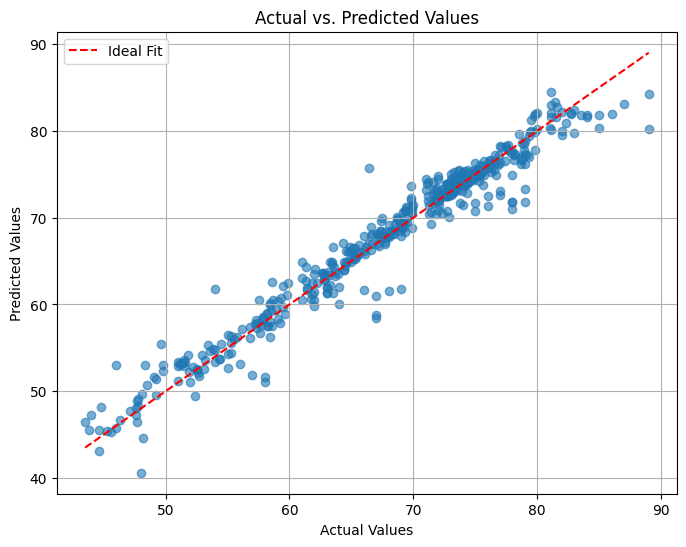

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ideal Fit')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.savefig(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\lazycat\1.png", dpi=300, bbox_inches="tight")
plt.show()

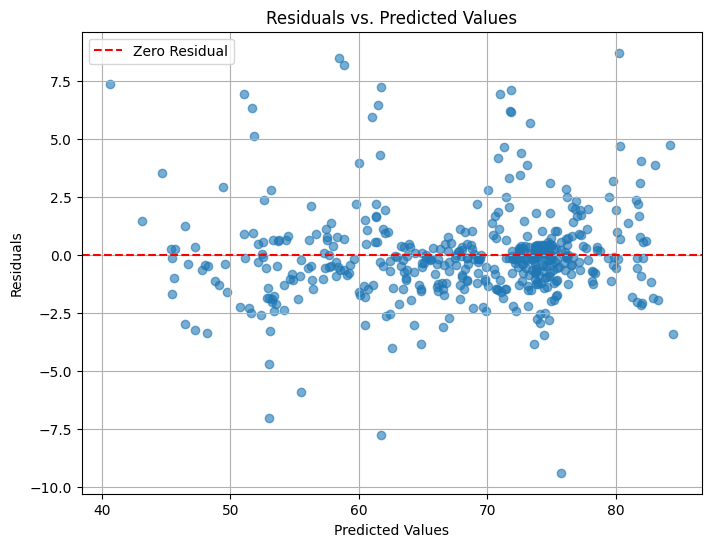

In [5]:
residuals = y_test.values.flatten() - y_pred.flatten()

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', label='Zero Residual')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True)
plt.savefig(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\lazycat\2.png", dpi=300, bbox_inches="tight")
plt.show()

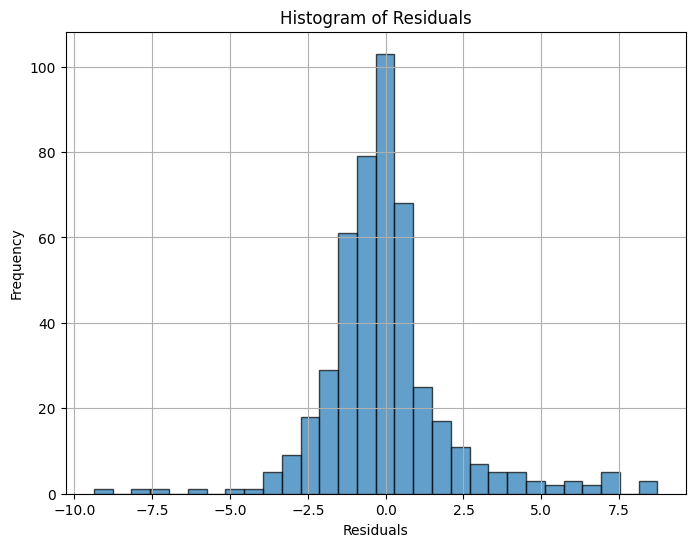

In [6]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.savefig(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\lazycat\3.png", dpi=300, bbox_inches="tight")
plt.show()

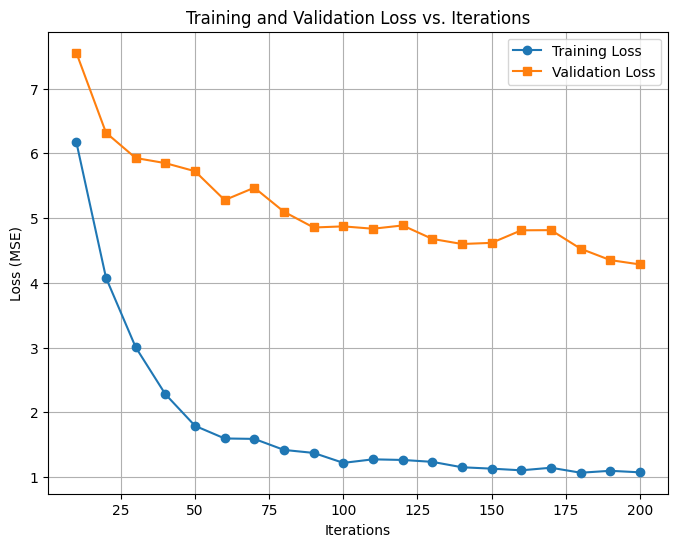

In [7]:
train_losses = []
val_losses = []

for iterations in range(10, 210, 10):
    temp_model = CatBoostRegressor(iterations=iterations, verbose=0)
    temp_model.fit(X_train, y_train)
    train_loss = mean_squared_error(y_train, temp_model.predict(X_train))
    val_loss = mean_squared_error(y_test, temp_model.predict(X_test))
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
plt.figure(figsize=(8, 6))
plt.plot(range(10, 210, 10), train_losses, marker='o', label='Training Loss')
plt.plot(range(10, 210, 10), val_losses, marker='s', label='Validation Loss')
plt.title('Training and Validation Loss vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.savefig(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\lazycat\4.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
import json

# Пример метрик
metrics = {
    "MAE": mae,
    "MSE": mse,
    "R2": r2
}

# Сохранение метрик в файл
with open(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\metrics\lazycat_metrics.json", "w") as f:
    json.dump(metrics, f)

In [9]:
import pickle

with open(r"C:\Users\mns94\PycharmProjects\tpu-8e21-ai-basis\Moiseev\jupyter\models\lazycat_model.pkl", "wb") as f:
    pickle.dump(model, f)